In [1]:
import pandas as pd

df = pd.read_csv('WDPA_Apr2026_Public_csv.csv')

C:\Users\craig\AppData\Local\Temp\ipykernel_54876\1597501024.py:3: DtypeWarning: Columns (0: SITE_PID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('WDPA_Apr2026_Public_csv.csv')


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 314613 entries, 0 to 314612
Data columns (total 34 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   TYPE        314613 non-null  str    
 1   SITE_ID     314613 non-null  int64  
 2   SITE_PID    314613 non-null  object 
 3   SITE_TYPE   314613 non-null  str    
 4   NAME_ENG    314613 non-null  str    
 5   NAME        314613 non-null  str    
 6   DESIG       314613 non-null  str    
 7   DESIG_ENG   314613 non-null  str    
 8   DESIG_TYPE  314613 non-null  str    
 9   IUCN_CAT    314613 non-null  str    
 10  INT_CRIT    314613 non-null  str    
 11  REALM       314613 non-null  str    
 12  REP_M_AREA  314613 non-null  float64
 13  GIS_M_AREA  306950 non-null  float64
 14  REP_AREA    314613 non-null  float64
 15  GIS_AREA    306950 non-null  float64
 16  NO_TAKE     313066 non-null  str    
 17  NO_TK_AREA  314613 non-null  float64
 18  STATUS      314613 non-null  str    
 19  STATUS_YR   3

In [3]:
df.value_counts("STATUS_YR").sort_index(ascending=False).head(20)

STATUS_YR
2025      182
2024     6823
2023     8703
2022     6278
2021     6316
2020     5319
2019     5890
2018     7340
2017     5468
2016     6283
2015     6828
2014     6396
2013     4867
2012     7031
2011    10114
2010     8342
2009     6163
2008     8129
2007     6554
2006     7661
Name: count, dtype: int64

In [4]:
%pip install matplotlib
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


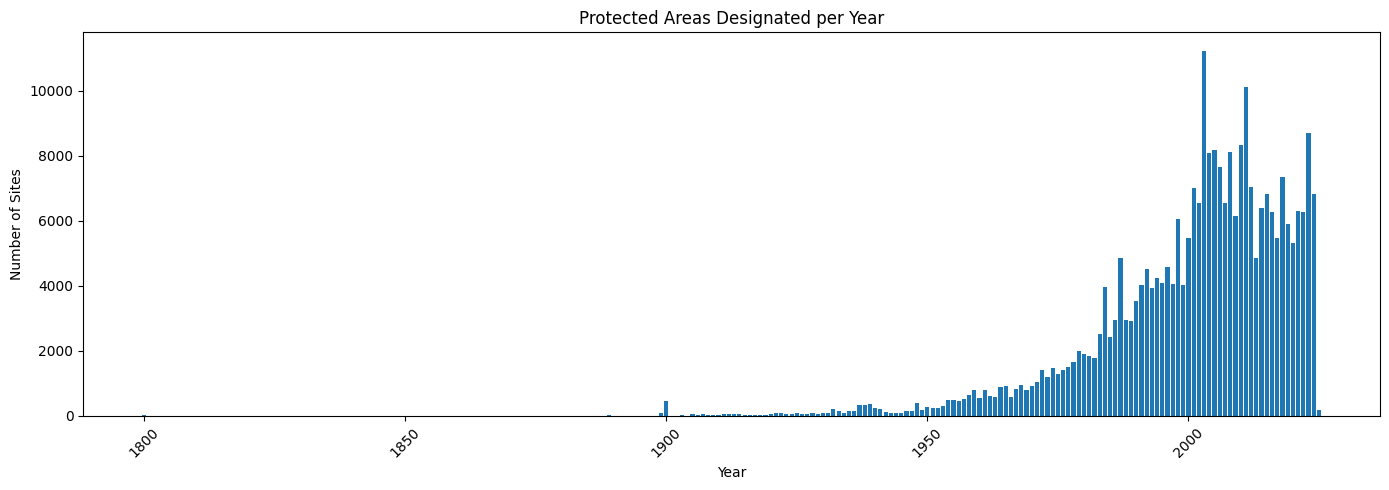

In [5]:

# Count sites per year, sorted chronologically
status_by_year = df[df["STATUS_YR"] != 0].value_counts("STATUS_YR").sort_index()


fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(status_by_year.index, status_by_year.values)

ax.set_title("Protected Areas Designated per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Sites")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



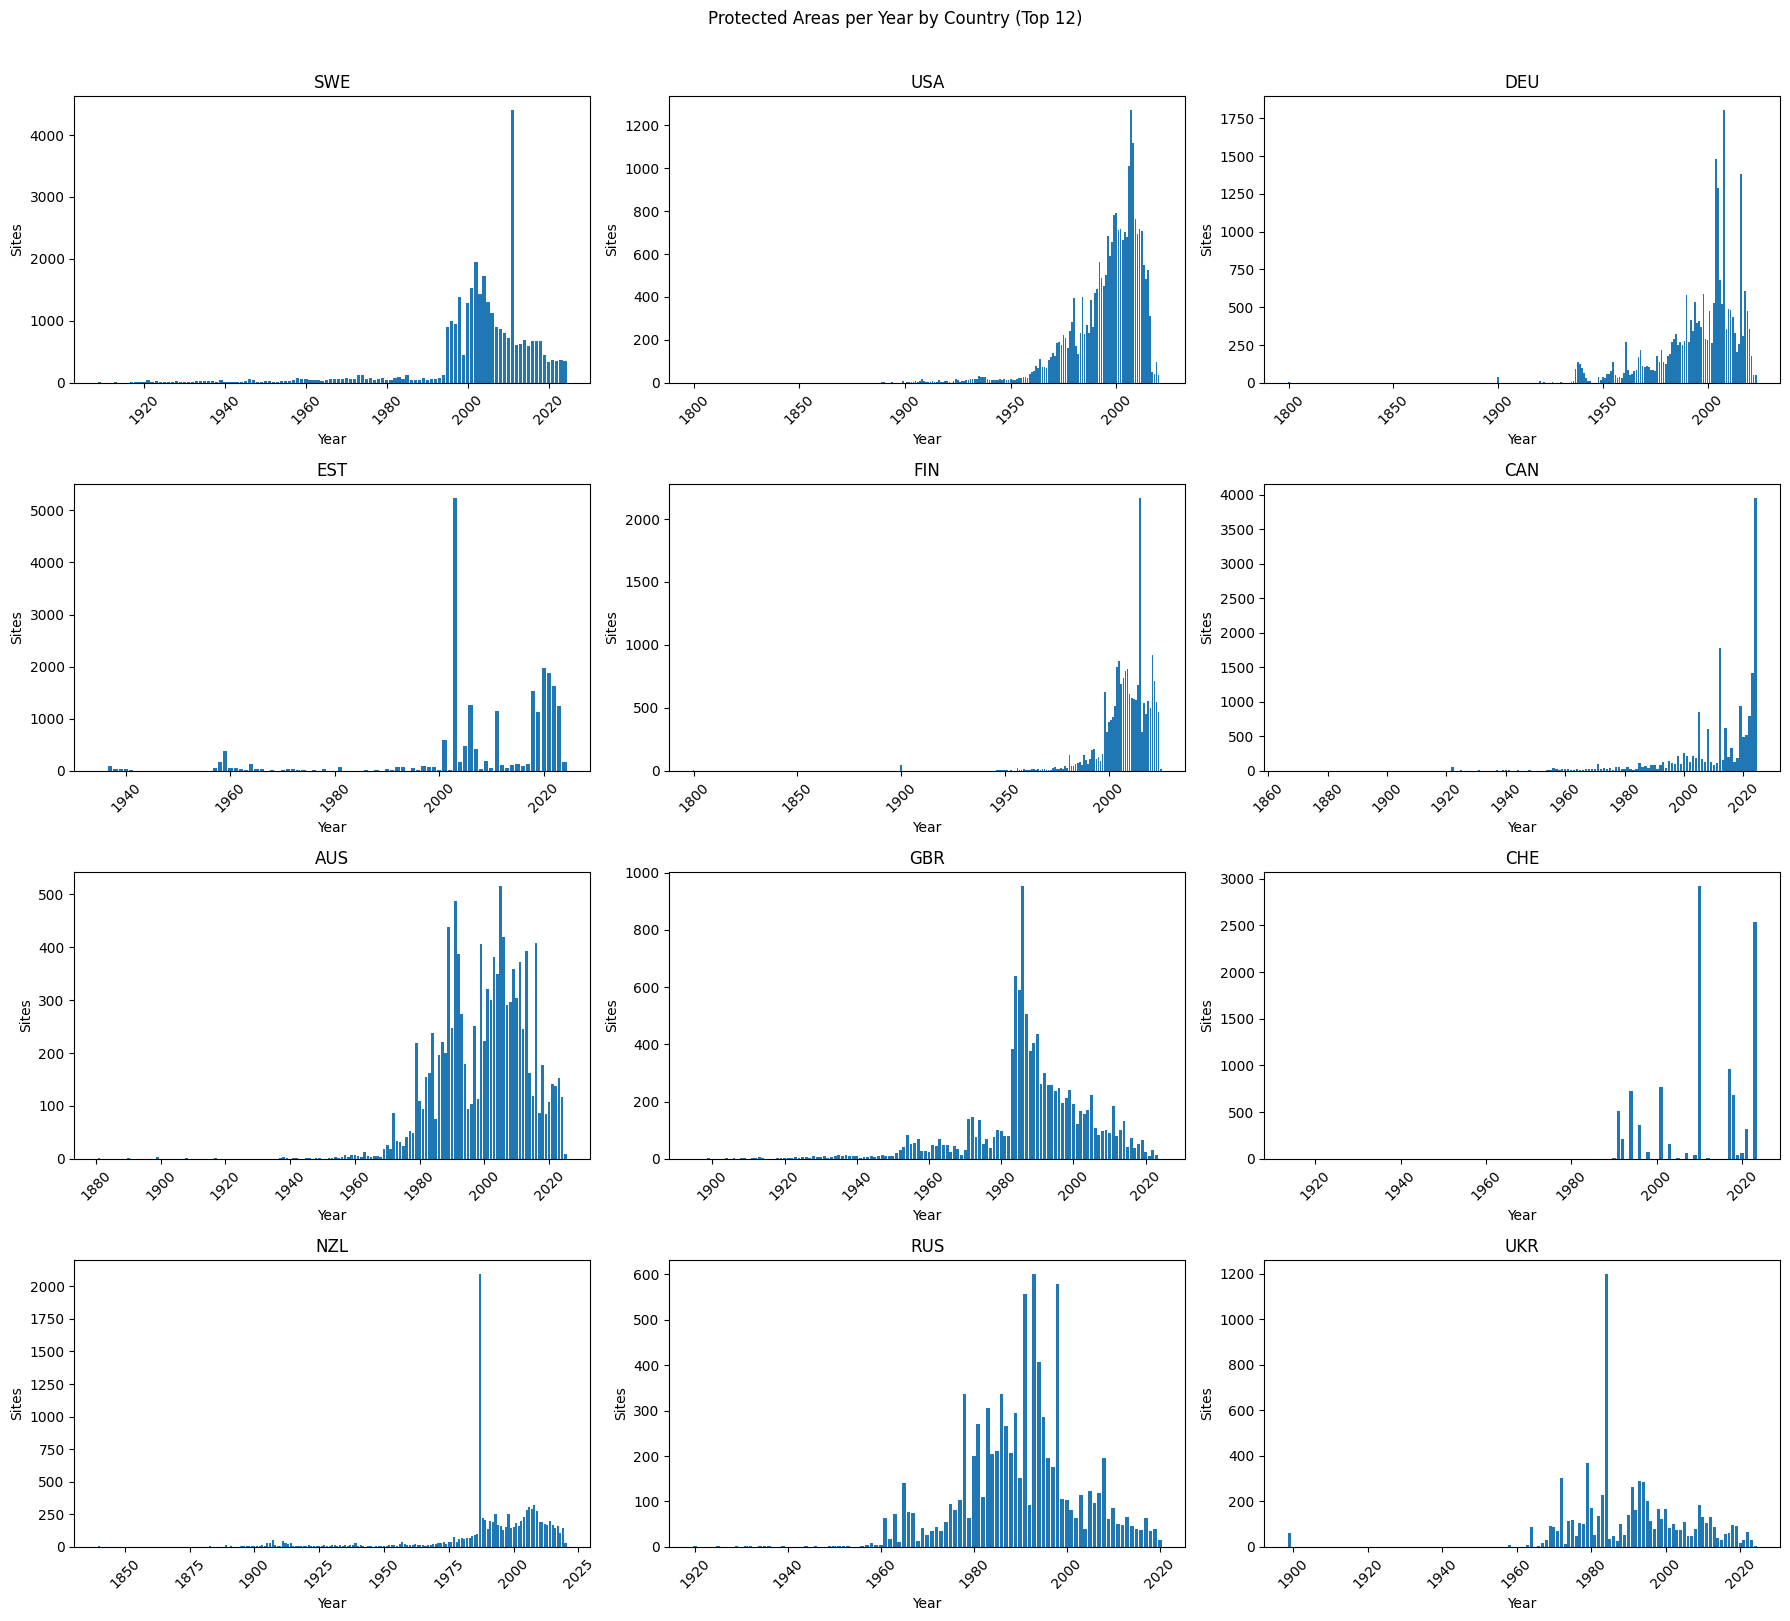

In [6]:
import matplotlib.pyplot as plt

# Filter out year 0, then get top 12 countries by total sites
df_clean = df[df["STATUS_YR"] != 0]
top_countries = df_clean["ISO3"].value_counts().head(12).index

# Group by country and year
grouped = (
    df_clean[df_clean["ISO3"].isin(top_countries)]
    .groupby(["ISO3", "STATUS_YR"])
    .size()
    .reset_index(name="count")
)

# Build facet grid
cols = 3
rows = 4
fig, axes = plt.subplots(rows, cols, figsize=(18, 16), sharey=False)
axes = axes.flatten()

for i, country in enumerate(top_countries):
    data = grouped[grouped["ISO3"] == country]
    axes[i].bar(data["STATUS_YR"], data["count"])
    axes[i].set_title(country)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Sites")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Protected Areas per Year by Country (Top 12)", y=1.01)
plt.tight_layout()
plt.show()


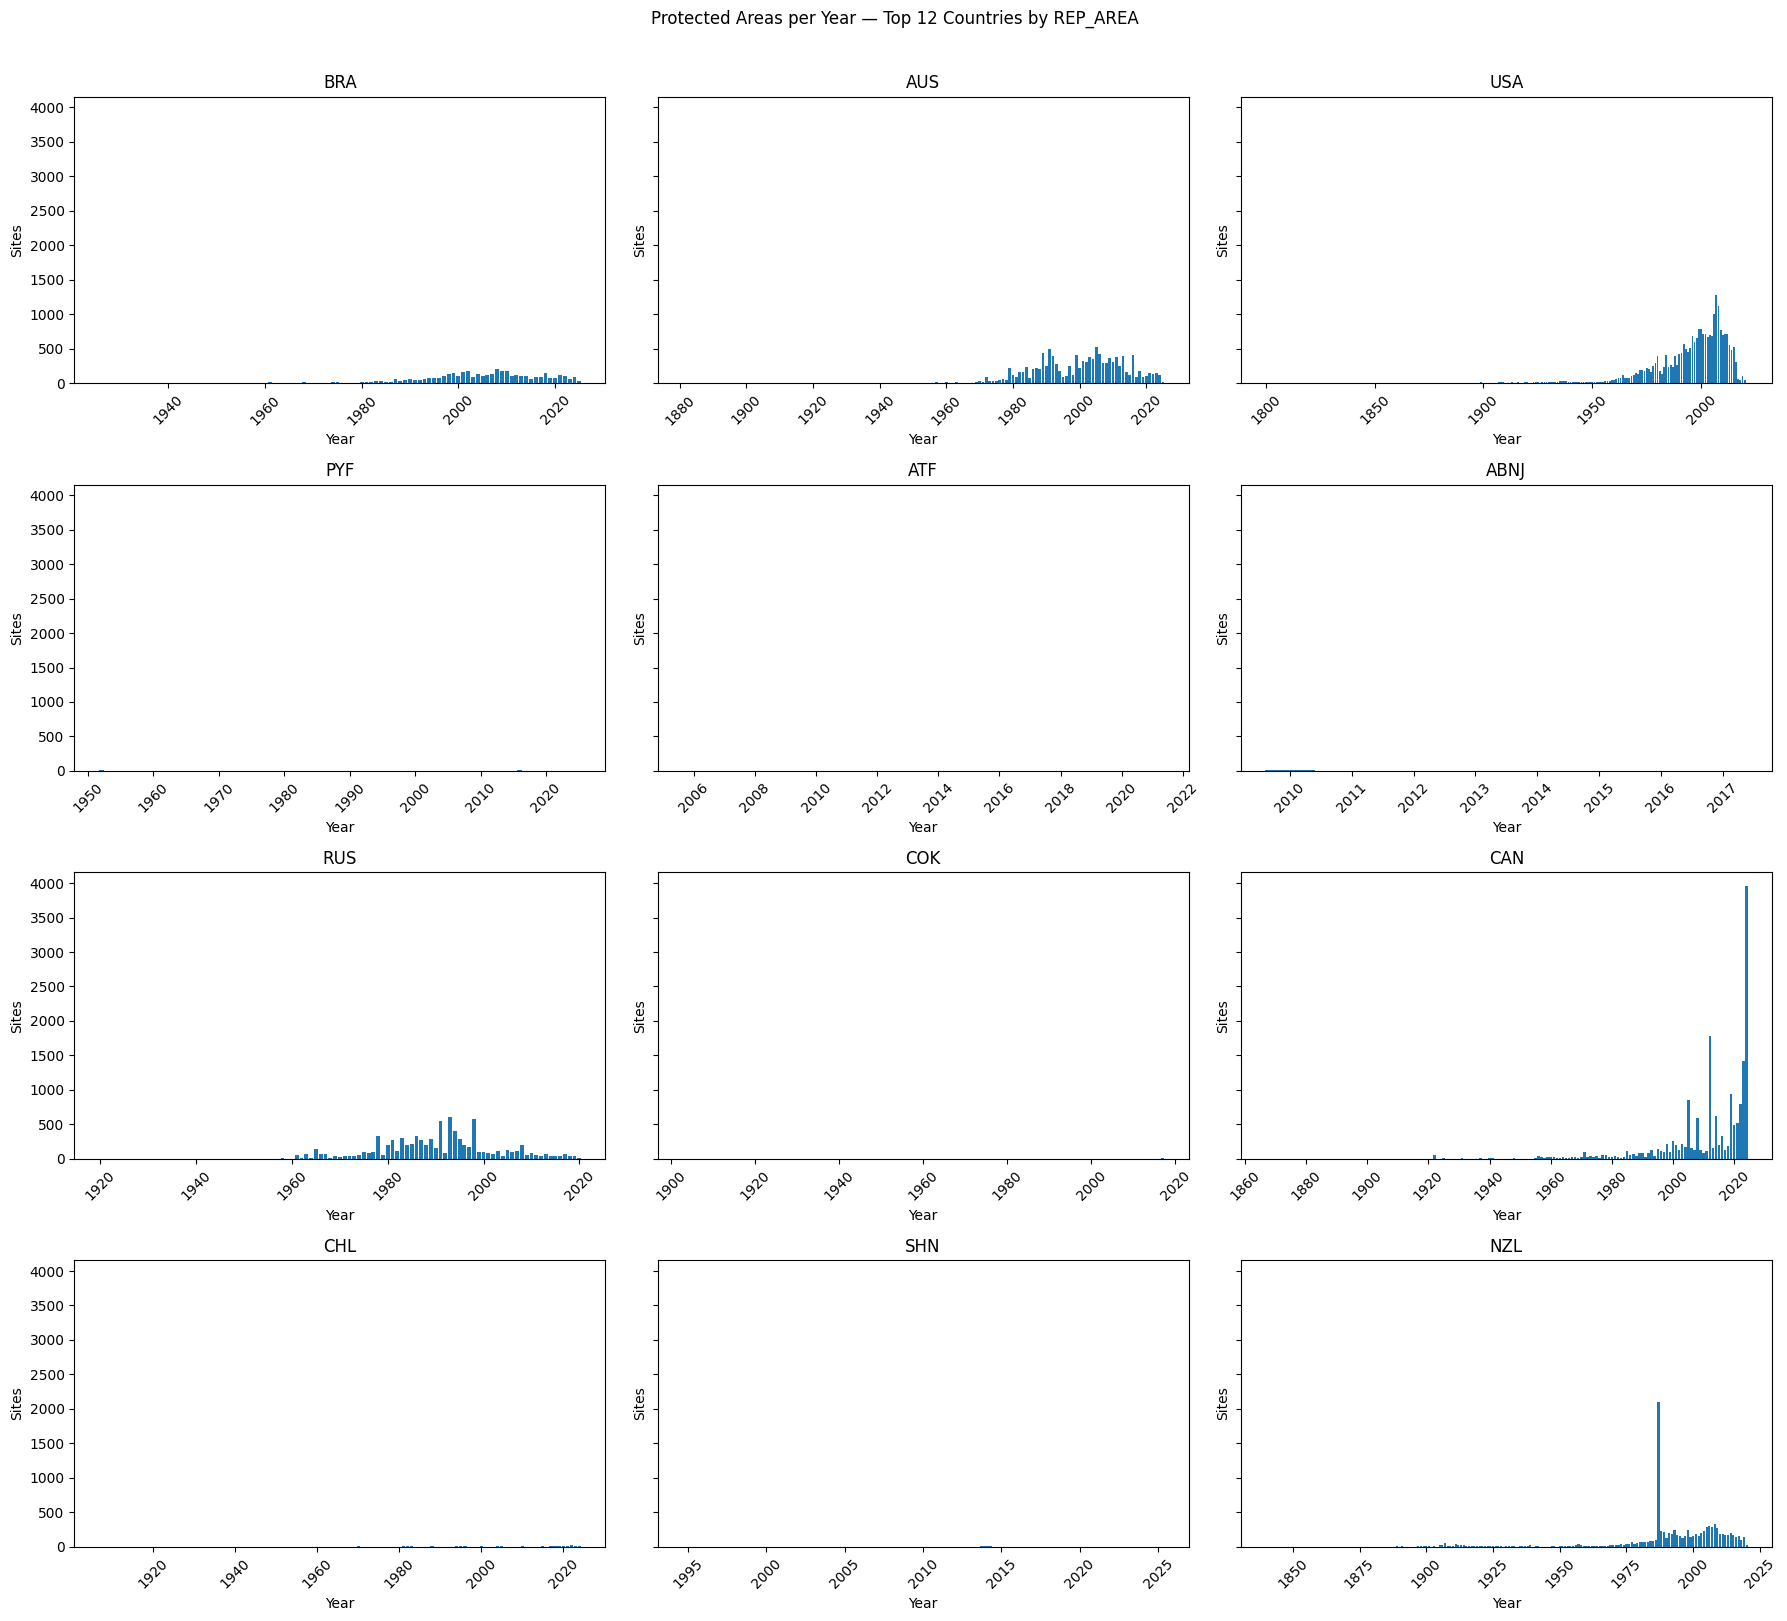

In [8]:
import matplotlib.pyplot as plt

df_clean = df[df["STATUS_YR"] != 0]

# Top 12 countries by total reported protected area
top_countries = (
    df_clean.groupby("ISO3")["REP_AREA"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

grouped = (
    df_clean[df_clean["ISO3"].isin(top_countries)]
    .groupby(["ISO3", "STATUS_YR"])
    .size()
    .reset_index(name="count")
)

cols = 3
rows = 4
fig, axes = plt.subplots(rows, cols, figsize=(18, 16), sharey=True)
axes = axes.flatten()

for i, country in enumerate(top_countries):
    data = grouped[grouped["ISO3"] == country]
    axes[i].bar(data["STATUS_YR"], data["count"])
    axes[i].set_title(country)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Sites")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Protected Areas per Year — Top 12 Countries by REP_AREA", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
total_area_by_country = df.groupby("ISO3")["REP_AREA"].sum().sort_values(ascending=False)
total_area_by_country.head(20)


ISO3
BRA        8.993152e+06
AUS        6.118676e+06
USA        6.090543e+06
PYF        4.576981e+06
ATF        3.392968e+06
ABNJ       3.244114e+06
RUS        2.574061e+06
MNP;UMI    2.540857e+06
COK        2.278077e+06
CAN        2.249106e+06
CHL        1.838778e+06
SHN        1.584315e+06
NZL        1.396481e+06
NCL        1.360243e+06
MEX        1.242815e+06
SGS        1.240000e+06
GRL        1.007726e+06
PCN        8.419470e+05
VEN        8.259558e+05
KIR        8.064552e+05
Name: REP_AREA, dtype: float64

In [ ]:
%pip install country_converter
import country_converter as coco

# Load and clean the country size data
country_sizes = pd.read_csv(r'C:\Users\craig\Desktop\Protected Areas\Country Area km^2 - Sheet1.csv')
country_sizes['ISO3'] = coco.convert(names=country_sizes['Country Name'], to='ISO3')
country_sizes['Total Area km^2'] = pd.to_numeric(country_sizes['Total Area km^2'].str.replace(',', ''), errors='coerce')

# Merge with protected area totals
protected = df.groupby('ISO3')['REP_AREA'].sum().reset_index()
protected.columns = ['ISO3', 'protected_area_km2']

merged = country_sizes.merge(protected, on='ISO3', how='left')
merged['pct_protected'] = (merged['protected_area_km2'] / merged['Total Area km^2'] * 100).round(2)

merged[['Country Name', 'Total Area km^2', 'protected_area_km2', 'pct_protected']]\
    .sort_values('pct_protected', ascending=False)\
    .head(20)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Country Name,Total Area km^2,protected_area_km2,pct_protected
213,Cook Islands,236,2.278077e+06,965286.78
201,Saint Helena,394,1.584315e+06,402110.35
195,Northern Mariana Islands,464,6.997647e+05,150811.37
196,Palau,459,6.086642e+05,132606.58
172,French Polynesia,4167,4.576981e+06,109838.75
185,Kiribati,811,8.064552e+05,99439.60
197,Seychelles,452,4.449476e+05,98439.74
214,American Samoa,199,1.047843e+05,52655.44
211,Niue,260,1.270593e+05,48868.95
203,Mayotte,374,6.846114e+04,18305.12


In [34]:
import country_converter as coco
pd.set_option('display.float_format', '{:,.0f}'.format)

# Load country land area
country_sizes = pd.read_csv(r'C:\Users\craig\Desktop\Protected Areas\Country Area km^2 - Sheet1.csv')
country_sizes['ISO3'] = coco.convert(names=country_sizes['Country Name'], to='ISO3')
country_sizes['Total Area km^2'] = pd.to_numeric(country_sizes['Total Area km^2'].str.replace(',', ''), errors='coerce')

# Load EEZ data
eez = pd.read_csv(r'C:\Users\craig\Desktop\Protected Areas\EEZ Size - Sheet2.csv')
eez['ISO3'] = coco.convert(names=eez['Country Name'], to='ISO3')

# Merge land + EEZ
country_sizes = country_sizes.merge(eez[['ISO3', 'EEZ Total km^2']], on='ISO3', how='left')
country_sizes['total_area_km2'] = country_sizes['Total Area km^2'] + country_sizes['EEZ Total km^2']

# Deduplicate by NAME_ENG before summing
protected = (
    df[df["STATUS_YR"] != 0]
    .drop_duplicates(subset="NAME_ENG")
    .groupby("ISO3")["REP_AREA"]
    .sum()
    .reset_index()
)
protected.columns = ["ISO3", "protected_area_km2"]

merged = country_sizes.merge(protected, on='ISO3', how='left')
merged['pct_protected'] = (merged['protected_area_km2'] / merged['total_area_km2'] * 100).round(2)
merged['continent'] = coco.convert(names=merged['ISO3'], to='continent')

merged[['Country Name', 'Total Area km^2', 'EEZ Total km^2', 'total_area_km2', 'protected_area_km2', 'pct_protected', 'continent']]\
    .sort_values('pct_protected', ascending=False)\
    .head(40)

merged.to_csv("merged.csv", index=False)
merged


Comores not found in regex


,Index,Country Name,Total Area km^2,World share %,ISO3,EEZ Total km^2,total_area_km2,protected_area_km2,pct_protected,continent
0,1,Russia,17098242,11.00%,RUS,"15,461,132","32,559,374","2,494,819",8,Europe
1,2,Canada,9984670,6.11%,CAN,"11,530,860","21,515,530","1,950,869",9,America
2,3,China,9706961,6.30%,CHN,"2,604,790","12,311,751","237,637",2,Asia
3,4,United States,9372610,6.14%,USA,"24,334,200","33,706,810","5,541,255",16,America
4,5,Brazil,8515767,5.61%,BRA,"7,355,328","15,871,095","8,946,751",56,America
...,...,...,...,...,...,...,...,...,...,...
230,230,Saint Barthélemy,21,0.00%,BLM,NaN,NaN,12,NaN,America
231,231,Tokelau,12,0.00%,TKL,NaN,NaN,10,NaN,Oceania
232,232,Gibraltar,6,0.00%,GIB,NaN,NaN,NaN,NaN,Europe
233,233,Monaco,2,0.00%,MCO,576,578,0,0,Europe


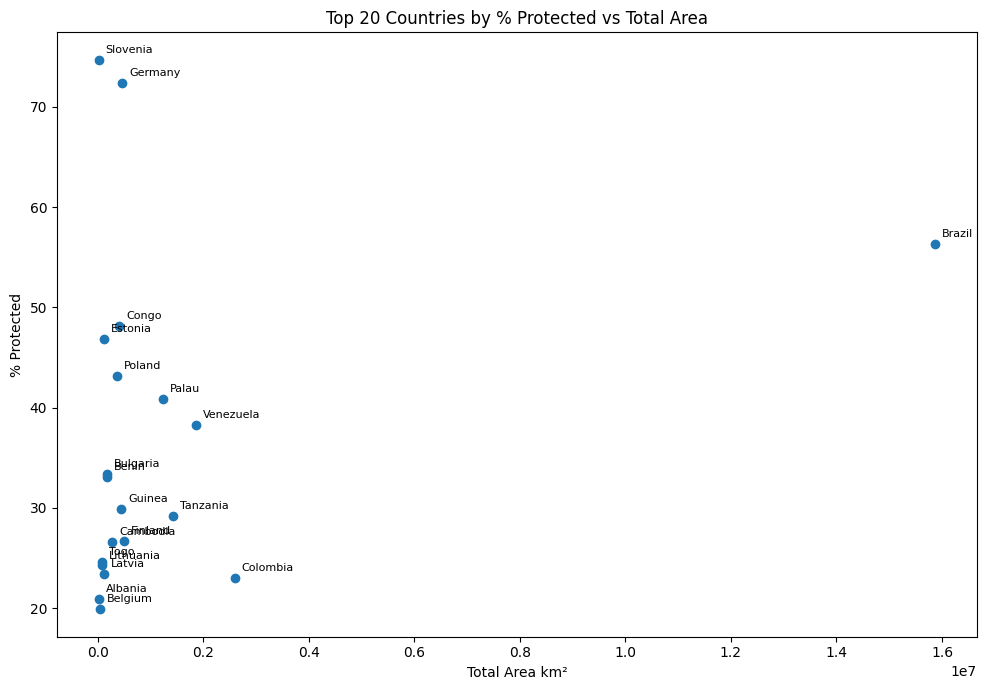

In [23]:
top20 = merged.sort_values('pct_protected', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(top20['total_area_km2'], top20['pct_protected'])

for _, row in top20.iterrows():
    ax.annotate(row['Country Name'], (row['total_area_km2'], row['pct_protected']),
                fontsize=8, textcoords="offset points", xytext=(5, 5))

ax.set_xlabel('Total Area km²')
ax.set_ylabel('% Protected')
ax.set_title('Top 20 Countries by % Protected vs Total Area')
plt.tight_layout()
plt.show()


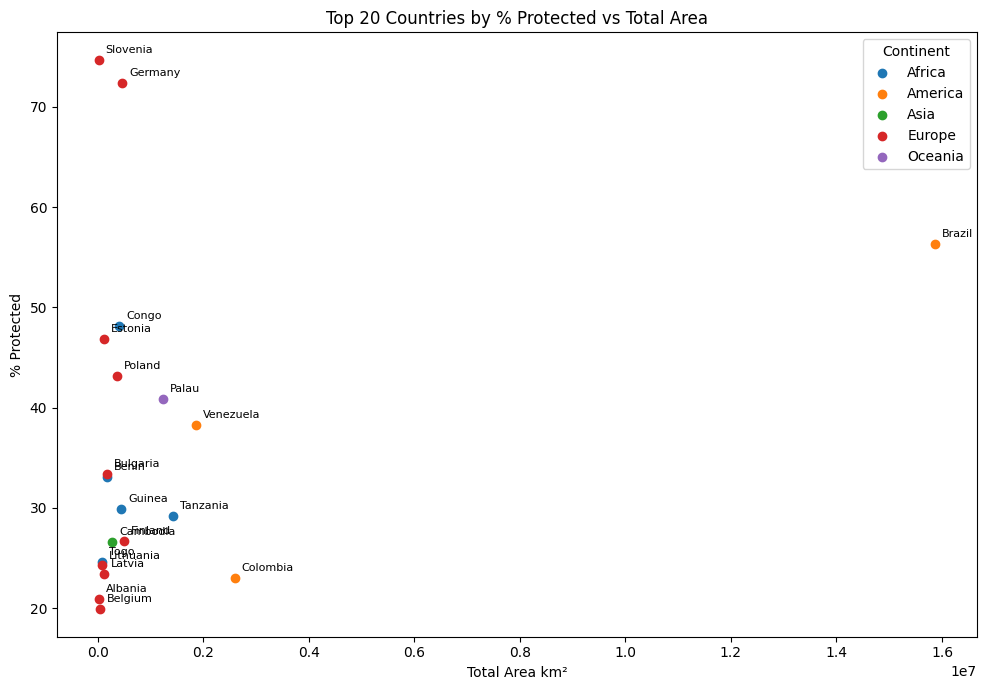

In [ ]:
top20 = merged.sort_values('pct_protected', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))

for continent, group in top20.groupby('continent'):
    ax.scatter(group['total_area_km2'], group['pct_protected'], label=continent)

for _, row in top20.iterrows():
    ax.annotate(row['Country Name'], (row['total_area_km2'], row['pct_protected']),
                fontsize=8, textcoords="offset points", xytext=(5, 5))
    

ax.set_xlabel('Total Area km²')
ax.set_ylabel('% Protected')
ax.set_title('Top 20 Countries by % Protected vs Total Area')
ax.legend(title='Continent')
plt.tight_layout()
plt.show()



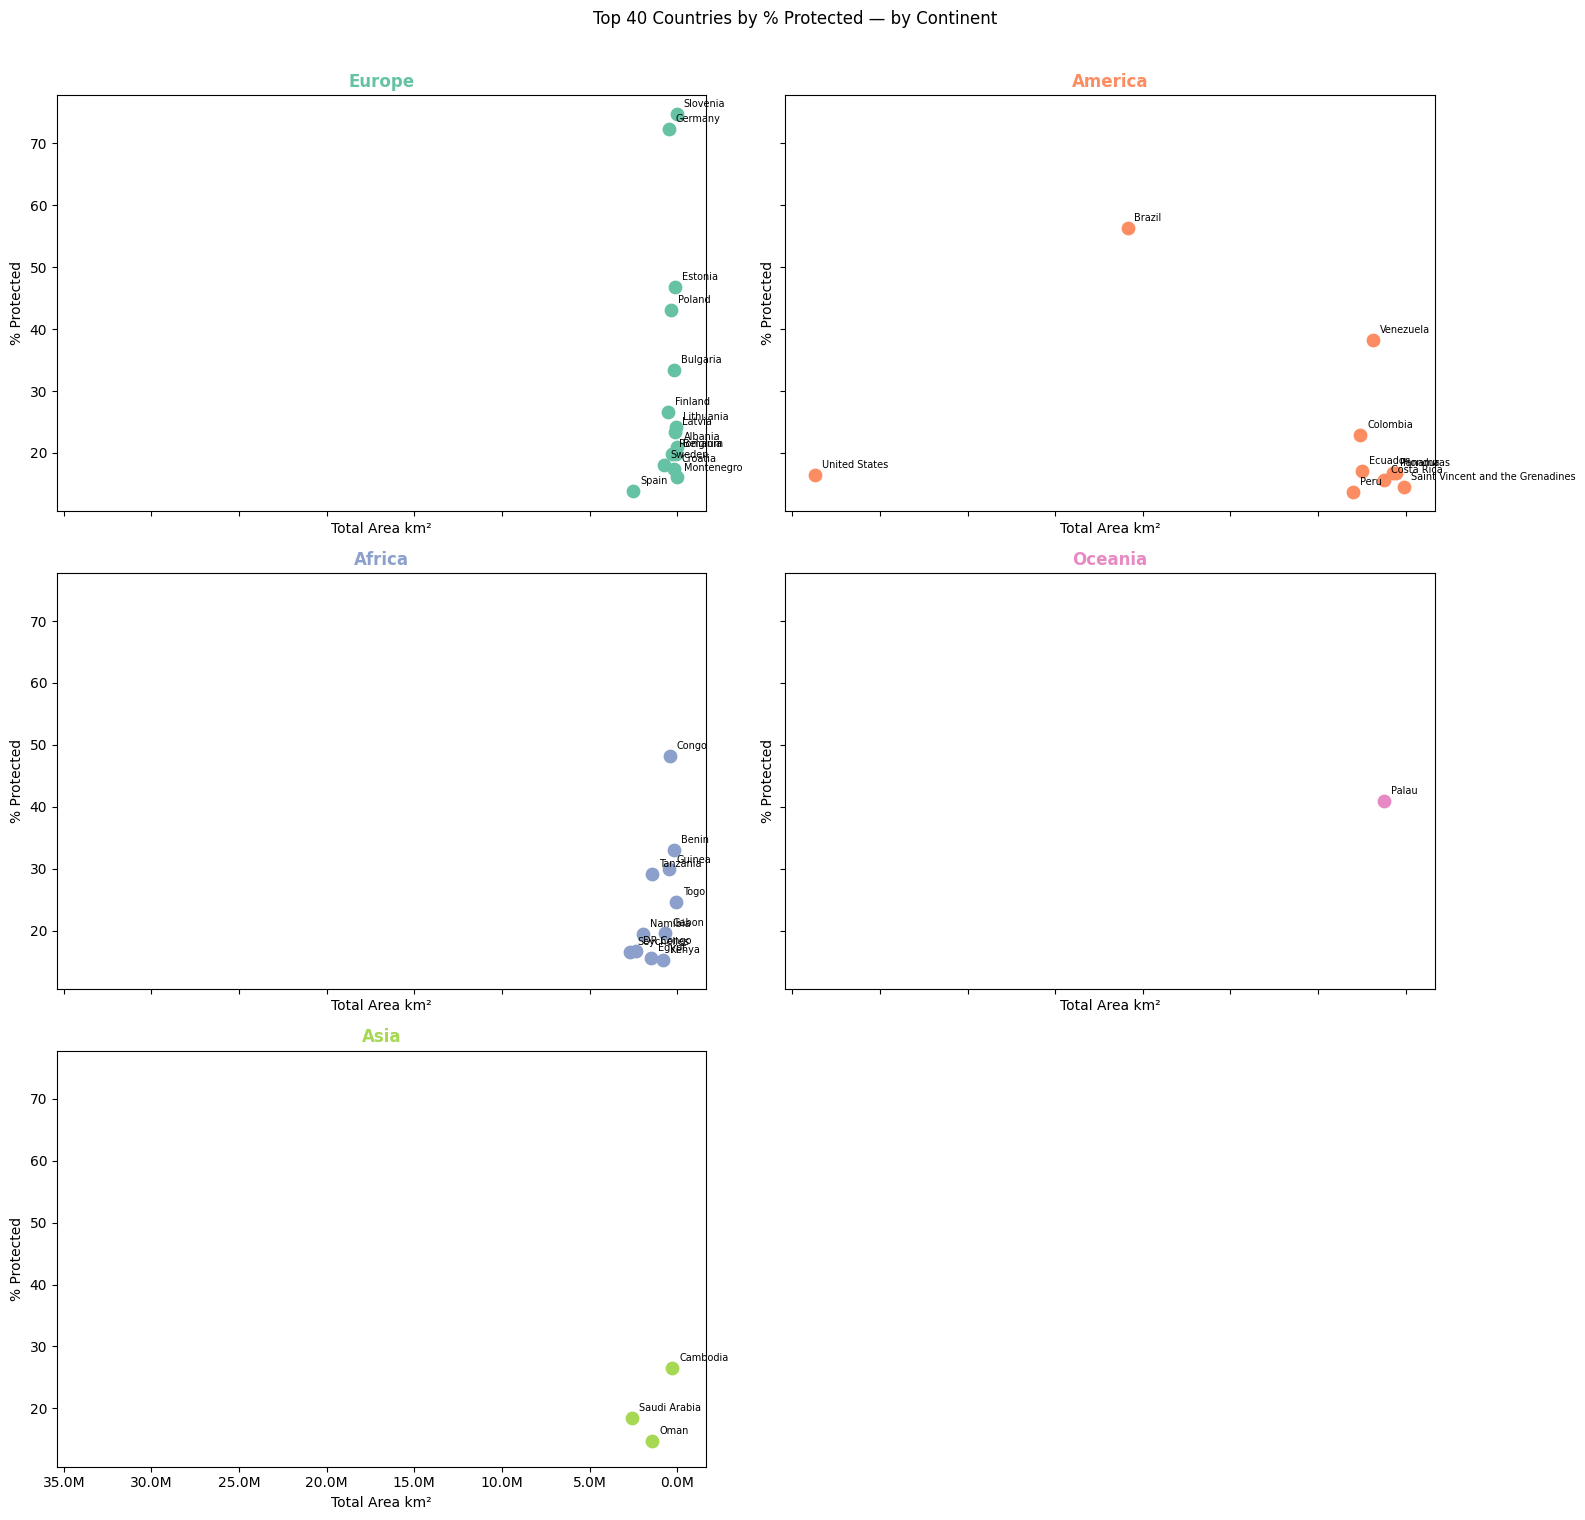

In [29]:
top40 = merged.sort_values('pct_protected', ascending=False).head(40)

continents = top40['continent'].unique()
cols = 2
rows = -(-len(continents) // cols)  # ceiling division

colors = plt.cm.Set2.colors
color_map = {c: colors[i] for i, c in enumerate(continents)}

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5), sharex=True, sharey=True)

axes = axes.flatten()

for i, continent in enumerate(continents):
    group = top40[top40['continent'] == continent]
    axes[i].scatter(group['total_area_km2'], group['pct_protected'], 
                    color=color_map[continent], s=80)
    for _, row in group.iterrows():
        axes[i].annotate(row['Country Name'], (row['total_area_km2'], row['pct_protected']),
                         fontsize=7, textcoords="offset points", xytext=(5, 5))
    axes[i].set_title(continent, color=color_map[continent], fontweight='bold')
    axes[i].set_xlabel('Total Area km²')
    axes[i].set_ylabel('% Protected')
    axes[0].invert_xaxis()

for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))


# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 40 Countries by % Protected — by Continent', y=1.01)
plt.tight_layout()
plt.savefig(rf'C:\Users\craig\Desktop\Protected Areas\Full Set.svg', format='svg')
plt.show()




In [22]:
for i, continent in enumerate(continents):
    group = top40[top40['continent'] == continent]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(group['total_area_km2'], group['pct_protected'],
               color=color_map[continent], s=80)
    for _, row in group.iterrows():
        ax.annotate(row['Country Name'], (row['total_area_km2'], row['pct_protected']),
                    fontsize=7, textcoords="offset points", xytext=(5, 5))
    ax.set_title(continent, color=color_map[continent], fontweight='bold')
    ax.set_xlabel('Total Area (M km²)')
    ax.set_ylabel('% Protected')
    ax.invert_xaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    
    plt.tight_layout()
    plt.savefig(rf'C:\Users\craig\Desktop\Protected Areas\{continent}.svg', format='svg')
    plt.close()

print("Done!")


Done!
